# Compare

In [189]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import requests
import json
import time
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Data

In [190]:
def load_and_clean_trrust(file_path):
    df = pd.read_csv(
        file_path,
        sep='\t',
        header=None,
        names=['TF', 'Target', 'Mode', 'Ref']
    )

    df['Mode'] = (
        df['Mode']
        .fillna('Unknown')
        .astype(str)
        .str.strip()
        .str.capitalize()
    )

    counts = df.groupby('TF')['Target'].transform('count')
    df = df[counts >= 1].copy()

    all_genes = sorted(
        list(set(df['TF']) | set(df['Target']))
    )

    gene_to_idx = {
        gene: i for i, gene in enumerate(all_genes)
    }

    print(f"Number of nodes: {len(all_genes)}")
    print(f"Number of regulatory relationships: {len(df)}")
    print(f"Mode values: {df['Mode'].unique()}")

    return df, gene_to_idx, all_genes


## Signed hypergraph

In [191]:
def build_hypergraph(df, gene_to_idx):
    n_nodes = len(gene_to_idx)

    hyperedges = []
    initial_signs = []

    for tf, group in df.groupby('TF'):

        nodes = [gene_to_idx[tf]]

        nodes.extend(
            gene_to_idx[target]
            for target in group['Target']
            if target in gene_to_idx
        )

        nodes = list(set(nodes))

        if len(nodes) < 2:
            continue

        hyperedges.append(nodes)

        modes = group['Mode'].str.lower()

        activation = (modes == 'activation').sum()
        repression = (modes == 'repression').sum()

        sign = 1 if activation >= repression else -1
        initial_signs.append(sign)

    n_edges = len(hyperedges)

    H = np.zeros(
        (n_nodes, n_edges),
        dtype=np.float64
    )

    for j, nodes in enumerate(hyperedges):
        H[nodes, j] = 1.0

    initial_signs = np.array(
        initial_signs,
        dtype=float
    )

    print(f"Number of hyperedges: {n_edges}")
    print(
        f"Positive hyperedges: {np.sum(initial_signs == 1)}"
    )
    print(
        f"Negative hyperedges: {np.sum(initial_signs == -1)}"
    )

    return H, initial_signs

## ASHD

In [192]:
def run_ashd_stable(H,initial_signs,n_clusters=15,n_iter=30,embedding_dim=64):
    n_nodes, n_edges = H.shape
    eps = 1e-10
    np.random.seed(42)
    X = np.random.normal(0,0.01,(n_nodes, embedding_dim))

    X /= (np.linalg.norm(X,axis=1,keepdims=True) + eps)

    W_diag = initial_signs.astype(float).copy()

    d_e = np.sum(H, axis=0) + eps
    D_e_inv = np.diag(1.0 / d_e)

    for t in range(n_iter):
        W_abs = np.abs(W_diag)
        d_v = np.sum(
            H * W_abs[np.newaxis, :],
            axis=1
        ) + eps

        D_v_inv_sqrt = np.diag(
            1.0 / np.sqrt(d_v))

        try:
            HW = H * W_diag[np.newaxis, :]
            P = (
                D_v_inv_sqrt
                @ HW
                @ D_e_inv
                @ H.T
                @ D_v_inv_sqrt
            )

            if (
                np.any(np.isnan(P))
                or np.any(np.isinf(P))
            ):
                print(
                    f"Warning: invalid diffusion matrix "
                    f"at iteration {t}"
                )
                continue

        except Exception as e:
            print(
                f"Diffusion failed at iteration {t}: {e}"
            )
            break

        X_new = P @ X

        X_new = np.nan_to_num(X_new,nan=0.0,posinf=0.0,neginf=0.0)

        norms = np.linalg.norm(
            X_new,
            axis=1,
            keepdims=True
        )

        norms = np.where(
            norms < eps,
            1.0,
            norms
        )

        X = X_new / norms

        # Adaptive hyperedge weight update
        if t % 3 == 0 and t > 0:
            for j in range(n_edges):
                idx = np.where(H[:, j] > 0)[0]
                if len(idx) < 2:
                    continue
                try:
                    sim = cosine_similarity(X[idx])
                    avg_sim = (
                        np.sum(sim) - len(idx)
                    ) / (
                        len(idx) * (len(idx) - 1)
                        + eps
                    )

                    W_diag[j] = np.clip(
                        W_diag[j] + 0.1 * avg_sim,
                        -1,
                        1
                    )

                except Exception:
                    continue

    X_final = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if np.all(X_final == 0):
        print("Error: final embeddings are all zero.")
        return None, X_final, W_diag

    kmeans = KMeans(
        n_clusters=15,
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_final)

    return labels, X_final, W_diag

# Evaluate

## Modularity: connection inside each cluster

In [193]:
def compute_modularity(H, labels):
    n_nodes, n_edges = H.shape
    m = n_edges  
    
    d_v = np.sum(H, axis=1)
    d_e = np.sum(H, axis=0)
    
    Q = 0.0
    unique_labels = np.unique(labels)
    
    for c in unique_labels:
        nodes_in_c = np.where(labels == c)[0]
        
        for e in range(n_edges):
            edge_nodes = np.where(H[:, e] > 0)[0]
            overlap = len(set(edge_nodes) & set(nodes_in_c))
            
            if overlap > 0:
                actual = overlap / d_e[e]
                expected = np.sum(d_v[nodes_in_c]) / (2 * m)
                Q += (actual - expected)
    
    return Q / m

## Silhouette

In [194]:
def compute_silhouette(embeddings, labels):
    try:
        unique, counts = np.unique(labels, return_counts=True)
        valid_mask = np.isin(labels, unique[counts > 1])
        
        if np.sum(valid_mask) < 2:
            return 0.0
        
        score = silhouette_score(embeddings[valid_mask], labels[valid_mask])
        return score
    except:
        return 0.0

## Biological Consistency

In [195]:
def compute_biological_consistency(embeddings, labels, top_k=50):
    unique_labels = np.unique(labels)
    consistencies = []
    
    for c in unique_labels:
        nodes_in_c = np.where(labels == c)[0]
        
        if len(nodes_in_c) < 2:
            continue
        
        if len(nodes_in_c) > top_k:
            nodes_in_c = np.random.choice(nodes_in_c, top_k, replace=False)
        
        cluster_embeddings = embeddings[nodes_in_c]
        sim_matrix = cosine_similarity(cluster_embeddings)
        
        # similarity
        n = len(nodes_in_c)
        avg_sim = (np.sum(sim_matrix) - n) / (n * (n - 1))
        consistencies.append(avg_sim)
    
    return np.mean(consistencies) if consistencies else 0.0

## Baseline

In [196]:
def baseline_kmeans(H,n_clusters=15):
    kmeans = KMeans(n_clusters=n_clusters,n_init=10,random_state=42)
    labels = kmeans.fit_predict(H)
    return labels, H


def baseline_spectral(H, n_clusters=15):
    n_nodes, n_edges = H.shape
    eps = 1e-10
    d_v = np.sum(H, axis=1) + eps
    d_e = np.sum(H, axis=0) + eps
    D_v_inv_sqrt = np.diag(1.0 / np.sqrt(d_v))
    D_e_inv = np.diag(1.0 / d_e)
    
    # Unsigned normalized adjacency matrix
    A = D_v_inv_sqrt @ H @ D_e_inv @ H.T @ D_v_inv_sqrt
    A = np.nan_to_num(A)
    
    # clustering from sklearn
    spectral = SpectralClustering(
        n_clusters=n_clusters, 
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=42
    )
    labels = spectral.fit_predict(A)
    
    # return eigenvalues
    from scipy.linalg import eigh
    eigenvalues, eigenvectors = eigh(A)
    embeddings = eigenvectors[:, -n_clusters:]  # max k 
    
    return labels, embeddings

def baseline_hypergcn(H, n_clusters=15, n_iter=30):
    n_nodes, n_edges = H.shape
    eps = 1e-10
    
    d_v = np.sum(H, axis=1)
    median_degree = np.median(d_v[d_v > 0])
    
    # H
    A = np.zeros((n_nodes, n_nodes))
    for e in range(n_edges):
        nodes = np.where(H[:, e] > 0)[0]
        if len(nodes) < 2:
            continue

        weight = 1.0 / len(nodes)
        for i in nodes:
            for j in nodes:
                if i != j:
                    A[i, j] += weight
    
    # GCN
    X = np.random.normal(0, 0.01, (n_nodes, 64))
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
    
    # norm
    d = np.sum(A, axis=1) + eps
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    
    for _ in range(n_iter):
        X = A_norm @ X
        X = np.nan_to_num(X)
        X = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
    
    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    
    return labels, X

## Compare 4 methods

In [197]:
def run_comparison_experiment(H, initial_signs, n_clusters=15):
    results = {}
    
    # ASHD 
    labels_ashd, emb_ashd, _ = run_ashd_stable(H, initial_signs, n_clusters)
    if labels_ashd is not None:
        results['ASHD'] = {
            'labels': labels_ashd,
            'embeddings': emb_ashd,
            'modularity': compute_modularity(H, labels_ashd),
            'silhouette': compute_silhouette(emb_ashd, labels_ashd),
            'bio_consistency': compute_biological_consistency(emb_ashd, labels_ashd)
        }
    
    # Plain KMeans
    labels_km, emb_km = baseline_kmeans(H, n_clusters)
    results['Plain KMeans'] = {
        'labels': labels_km,
        'embeddings': emb_km,
        'modularity': compute_modularity(H, labels_km),
        'silhouette': compute_silhouette(emb_km, labels_km),
        'bio_consistency': compute_biological_consistency(emb_km, labels_km)
    }
    
    # Spectral Clustering
    labels_sp, emb_sp = baseline_spectral(H, n_clusters)
    results['Spectral'] = {
        'labels': labels_sp,
        'embeddings': emb_sp,
        'modularity': compute_modularity(H, labels_sp),
        'silhouette': compute_silhouette(emb_sp, labels_sp),
        'bio_consistency': compute_biological_consistency(emb_sp, labels_sp)
    }
    
    # HyperGCN
    labels_hgcn, emb_hgcn = baseline_hypergcn(H, n_clusters)
    results['HyperGCN'] = {
        'labels': labels_hgcn,
        'embeddings': emb_hgcn,
        'modularity': compute_modularity(H, labels_hgcn),
        'silhouette': compute_silhouette(emb_hgcn, labels_hgcn),
        'bio_consistency': compute_biological_consistency(emb_hgcn, labels_hgcn)
    }
    
    return results

In [198]:
def print_results_table(results):
    print(f"{'Method':<20} {'Modularity':<15} {'Silhouette':<15} {'Bio-Consistency':<15}")
    
    for method, metrics in results.items():
        print(f"{method:<20} {metrics['modularity']:<15.4f} "
              f"{metrics['silhouette']:<15.4f} {metrics['bio_consistency']:<15.4f}")

In [199]:
if __name__ == "__main__":
    # print(f"{H.shape[0]}vertices, {H.shape[1]}edges")
    results = run_comparison_experiment(H, signs, n_clusters=15)
    print_results_table(results)

Method               Modularity      Silhouette      Bio-Consistency
ASHD                 -3.7667         0.6445          0.5213         
Plain KMeans         -2.1744         0.1070          0.3505         
Spectral             -4.5824         -0.6871         0.5348         
HyperGCN             -4.5131         0.9758          0.3868         


## KEGG enrichment picture

In [200]:
def enrichr_analysis(
    gene_list,
    cluster_id,
    library='KEGG_2021_Human'
):
    url = 'https://maayanlab.cloud/Enrichr/addList'

    payload = {
        'list': (None, '\n'.join(gene_list)),
        'description': (None, f'ASHD_Cluster_{cluster_id}')
    }

    try:
        response = requests.post(
            url,
            files=payload,
            timeout=10
        )

        if not response.ok:
            return None

        user_list_id = response.json()['userListId']

        query_url = (
            'https://maayanlab.cloud/Enrichr/enrich'
            f'?userListId={user_list_id}'
            f'&backgroundType={library}'
        )

        response = requests.get(
            query_url,
            timeout=10
        )

        if not response.ok:
            return None

        data = response.json()

        time.sleep(0.3)

        return data.get(library, [])[:1]

    except Exception:
        return None

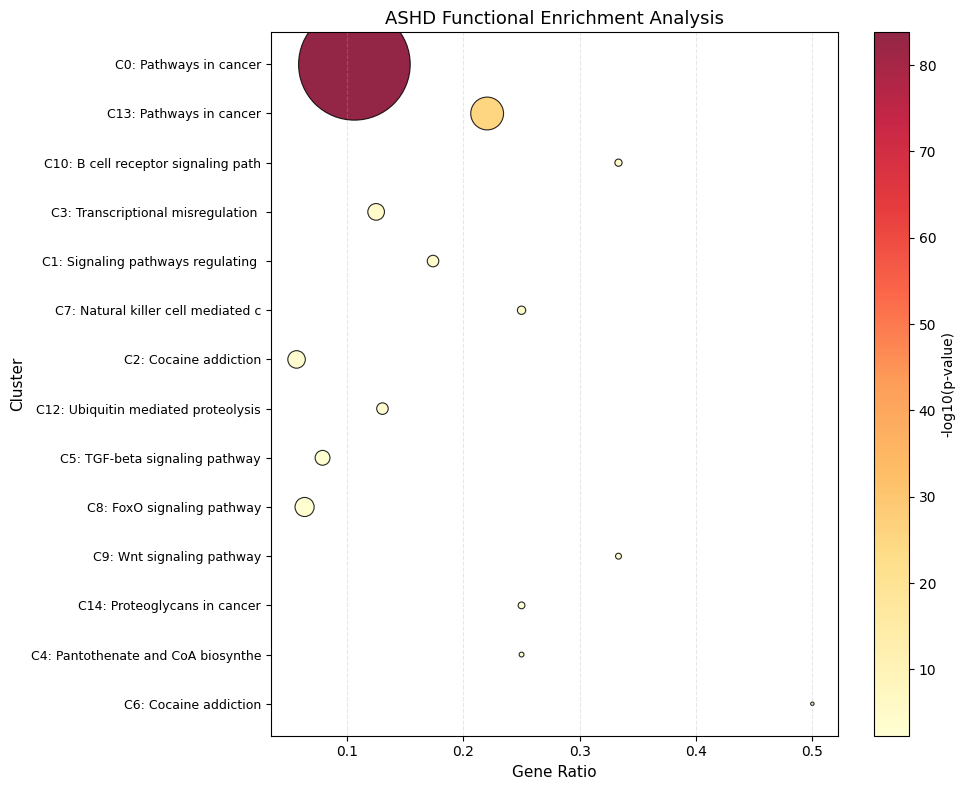

In [201]:
def enrichment(
    clusters,
    library='KEGG_2021_Human'
):

    plot_data = []
    cluster_ids = sorted(clusters.keys())[:15]

    for cid in cluster_ids:

        genes = clusters[cid]

        if len(genes) < 2:
            continue

        results = enrichr_analysis(
            genes,
            cid,
            library
        )

        if not results:
            continue

        term_data = results[0]

        term_name = (
            term_data[1]
            .split('_')[0][:30]
        )

        p_value = max(
            float(term_data[2]),
            1e-300
        )

        genes_raw = term_data[5]

        if isinstance(genes_raw, list):
            genes_list = genes_raw

        elif isinstance(genes_raw, str):
            genes_list = [
                g.strip()
                for g in genes_raw.split(';')
                if g.strip()
            ]

        else:
            genes_list = []

        cluster_size = len(genes)

        gene_ratio = (
            len(genes_list) / cluster_size
            if cluster_size > 0
            else 0
        )

        plot_data.append({
            'Cluster': cid,
            'Label': f'C{cid}',
            'Term': term_name,
            'Gene Ratio': gene_ratio,
            'P-value': p_value,
            'Cluster Size': cluster_size
        })

    if not plot_data:
        return

    df = pd.DataFrame(plot_data)

    df['-log10(p)'] = -np.log10(
        df['P-value']
    )

    df = df.sort_values(
        '-log10(p)',
        ascending=True
    )

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    scatter = ax.scatter(
        df['Gene Ratio'],
        range(len(df)),
        s=df['Cluster Size'] * 3,
        c=df['-log10(p)'],
        cmap='YlOrRd',
        alpha=0.85,
        edgecolors='black',
        linewidth=0.8
    )

    ax.set_yticks(
        range(len(df))
    )

    ax.set_yticklabels(
        [
            f"{row['Label']}: {row['Term']}"
            for _, row in df.iterrows()
        ],
        fontsize=9
    )

    ax.set_xlabel(
        'Gene Ratio',
        fontsize=11
    )

    ax.set_ylabel(
        'Cluster',
        fontsize=11
    )

    ax.set_title(
        'ASHD Functional Enrichment Analysis',
        fontsize=13
    )

    ax.grid(
        axis='x',
        alpha=0.3,
        linestyle='--'
    )

    cbar = plt.colorbar(
        scatter,
        ax=ax
    )

    cbar.set_label(
        '-log10(p-value)',
        fontsize=10
    )

    plt.tight_layout()

    plt.savefig(
        'ashd_Enrichment.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


enrichment(
    clusters,
    library='KEGG_2021_Human'
)

## Heatmap

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

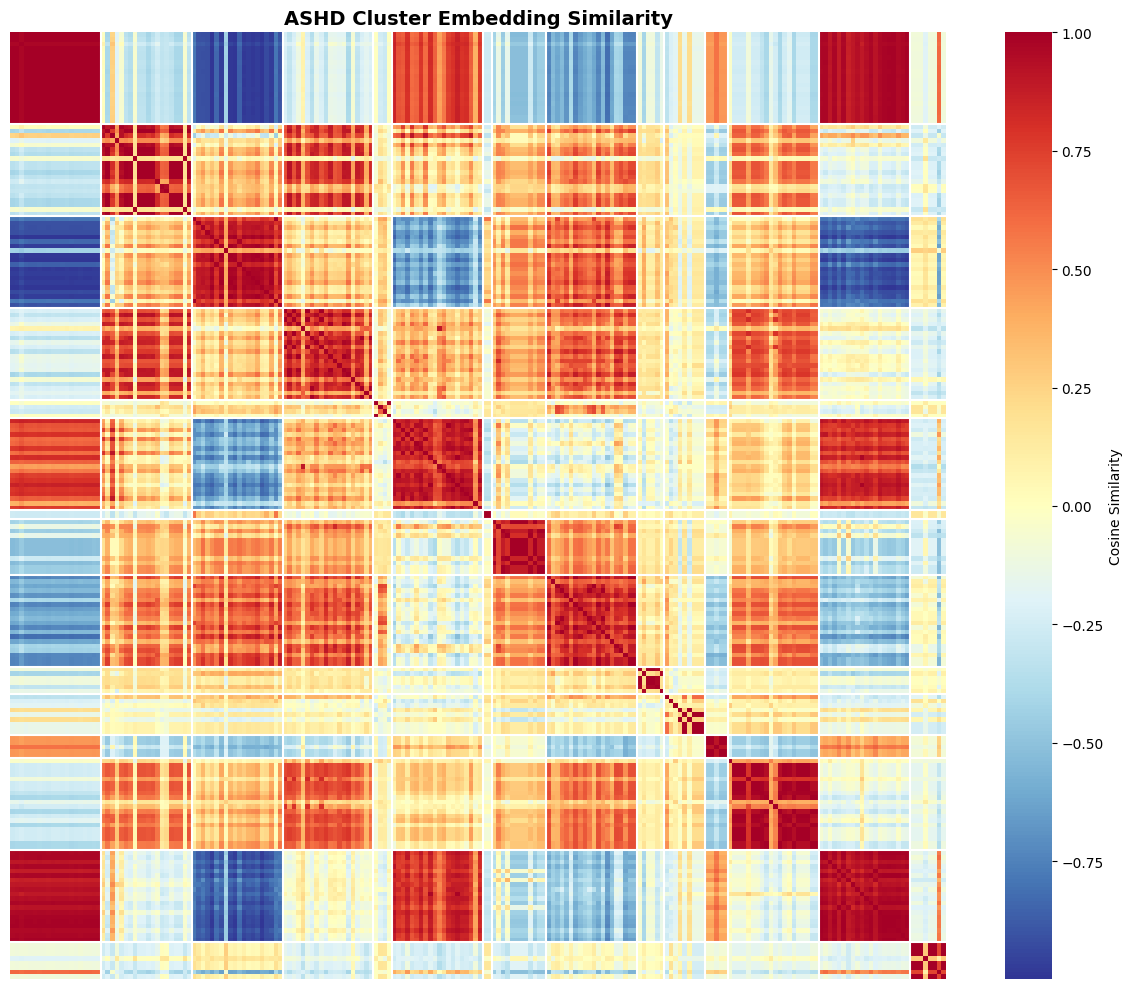

In [ ]:
def heatmap(
    embeddings,
    labels,
    n_clusters=15,
    n_sample_per_cluster=20
):

    unique_labels = sorted(
        np.unique(labels)
    )[:n_clusters]

    sampled_indices = []
    cluster_sizes = []

    for label in unique_labels:

        cluster_indices = np.where(
            labels == label
        )[0]

        n_sample = min(
            n_sample_per_cluster,
            len(cluster_indices)
        )

        sampled = np.random.choice(
            cluster_indices,
            n_sample,
            replace=False
        )

        sampled_indices.extend(sampled)
        cluster_sizes.append(n_sample)

    sampled_embeddings = embeddings[
        sampled_indices
    ]

    sim_matrix = cosine_similarity(
        sampled_embeddings
    )

    fig, ax = plt.subplots(
        figsize=(12, 10)
    )

    sns.heatmap(
        sim_matrix,
        cmap='RdYlBu_r',
        center=0,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={
            'label': 'Cosine Similarity'
        },
        ax=ax
    )

    boundaries = np.cumsum(
        cluster_sizes
    )[:-1]

    for boundary in boundaries:

        ax.axhline(
            boundary,
            color='white',
            linewidth=1.5
        )

        ax.axvline(
            boundary,
            color='white',
            linewidth=1.5
        )

    ax.set_title(
        'ASHD Cluster Embedding Similarity',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        'ashd_cluster_similarity_heatmap.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


heatmap(
    final_embeddings,
    labels,
    n_clusters=15,
    n_sample_per_cluster=20
)